# Solving the Poisson equation again
This tutorial follows the web-tutorial https://jsdokken.com/dolfinx-tutorial/chapter1/fundamentals_code.html# to get started with fenicsx. The goal is to solve a simple Poisson equation with only Dirichlet boundaries and a constant right hand side such that we know the exact solution.

In [1]:
from mpi4py import MPI 
from petsc4py.PETSc import ScalarType # type: ignore

import numpy as np
import matplotlib.pyplot as plt

import ufl
from dolfinx import fem, io, mesh, plot
from dolfinx.fem.petsc import LinearProblem

from visualization_fct import plot_mesh

Problem: $-\Delta u = f ~ on ~ \Omega, u = u_0 ~ on ~ \partial \Omega$. With $\Omega = [0,1]^2$. <br>
Where $f(x,y)=-6,~ u_0(x,y)=1+x^2+2y^2$. This has the exact solution $u_e(x,y)=1+x^2+2y^2$.


### Create a mesh

In [2]:
domain = mesh.create_unit_square(comm=MPI.COMM_WORLD, nx = 6, ny = 4, cell_type=mesh.CellType.triangle)
V = fem.functionspace(domain, ("Lagrange", 1)) # first order Lagrange fct. space -> degrees of freedom are located at the vertices of each cell
plot_mesh(V)

2026-03-11 11:03:29.935 (   3.579s) [    77E2A3E02600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

### Define boundary conditions

In [3]:
uD = fem.Function(V)
uD.interpolate(lambda x: 1 + x[0]**2 + 2*x[1]**2)

In [4]:
# Apply boundary data to all degrees of freedom that are on the boundary of the discrete domain
tdim = domain.topology.dim
fdim = tdim - 1 # dimension of the facets (e.g. 2D -> line, 3D -> face)
domain.topology.create_connectivity(fdim, tdim) # connect facets to cells
boundary_facets = mesh.exterior_facet_indices(domain.topology) # determine boundary facets 

Because here we work with first order Lagrange function space, the degrees of freedom are located at the vertices of each cell, thus each facet contains two degrees of freedom.

#### Local ordering of degrees of freedom and mesh vertices

Many people expect there to be a 1-1 correspondence between the mesh coordinates and the coordinates of the degrees of freedom. However, this is only true in the case of Lagrange 1 elements on a first order mesh. Therefore, in DOLFINx we use separate local numbering for the mesh coordinates and the dof coordinates. To obtain the local dof coordinates we can use `V.tabulate_dof_coordinates()`, while the ordering of the local vertices can be obtained by `mesh.geometry.x`.

In [5]:
boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets) # find local indices of the boundary degrees of freedom
bc = fem.dirichletbc(uD, boundary_dofs) # appy boundary conditions to boundary.

### Define variational problem

In [6]:
# Define trial and test function
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
# no need to have trial and test space, because boundary conditions are not part of the function space in FEniCSx

In [7]:
# Define constant source term
from dolfinx import default_scalar_type
f = fem.Constant(domain, default_scalar_type(-6)) # the fem.constant allows for later updating the value in f by using f.value =. Also because we indicate that f is constant, we speed up computation time.

In [8]:
# Define the variational problem
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f*v*ufl.dx

### Form and solve the problem

In [9]:
# Forming + Solving the problem
problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="Poisson"
)
uh = problem.solve()

### Error computation

In [10]:
V2 = fem.functionspace(domain, ("Lagrange", 2)) # functionspace for exact solution should have higher dimension than for numerical
uex = fem.Function(V2, name="u_exact")
uex.interpolate(lambda x: 1 + x[0]**2 + 2*x[1]**2) # interpolate the exact solution into function space containing it


In [11]:
# Calculate L2-error
L2_error = fem.form(ufl.inner(uh - uex, uh - uex) * ufl.dx)
error_local = fem.assemble_scalar(L2_error)
error_L2 = np.sqrt(domain.comm.allreduce(error_local, op=MPI.SUM))

In [12]:
# Maximum error at any degree of freedom (should be within machine precision)
error_max =np.max(np.abs(uD.x.array - uh.x.array))
if domain.comm.rank == 0:  # Only print the error on one process
    print(f"Error_L2 : {error_L2:.2e}")
    print(f"Error_max : {error_max:.2e}")

Error_L2 : 2.72e-02
Error_max : 8.88e-16


The maximum error at any degree of freedom (Knotenpunkte der Zellen) should be within machine precision in this case. This is because the finite element method with a rectangular domain uniformly partitioned into linear triangular elements will exactly reproduce a second-order polynomial at the vertices of the cells.

### Plot the mesh and the solution

In [13]:
# Plot with pyvista
import pyvista as pv
print(pv.global_theme.jupyter_backend)
pv.set_jupyter_backend("html")

html


In [14]:
print(pv.global_theme.jupyter_backend)

html


In [15]:
domain.topology.create_connectivity(tdim, tdim)
topology, cell_types, geometry = plot.vtk_mesh(domain, tdim)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)

In [16]:
plotter = pv.Plotter()
plotter.add_mesh(grid, show_edges=True)
plotter.view_xy()
if not pv.OFF_SCREEN:
    plotter.show()
else:
    figure = plotter.screenshot("fundamentals_mesh.png")

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [17]:
#  Plot solution uh
u_topology, u_cell_types, u_geometry = plot.vtk_mesh(V)
u_grid = pv.UnstructuredGrid(u_topology, u_cell_types, u_geometry)
u_grid.point_data["u"] = uh.x.array.real
u_grid.set_active_scalars("u")
u_plotter = pv.Plotter()
u_plotter.add_mesh(u_grid, show_edges=True)
u_plotter.view_xy()
if not pv.OFF_SCREEN:
    u_plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [18]:
# Warp mesh to make use of 3D-plotting
warped = u_grid.warp_by_scalar()
plotter2 = pv.Plotter()
plotter2.add_mesh(warped, show_edges=True, show_scalar_bar=True)
if not pv.OFF_SCREEN:
    plotter2.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

### Examining the discrete solution
The discrete solution $u_h$ is spanned up by the global basis functions $\phi_j$: $u_h = \sum\limits_{j=1}^N U_j\phi_j$ where we also call the $U_j$ the degrees of freedom of $u_h$. For Lagrange elements the $U_j$ are the value of $u_h$ at the node with global number $j$.

In [ ]:
u_nodal_values = uh.x.array # convert the U_j into a numpy array.
type(u_nodal_values)

numpy.ndarray

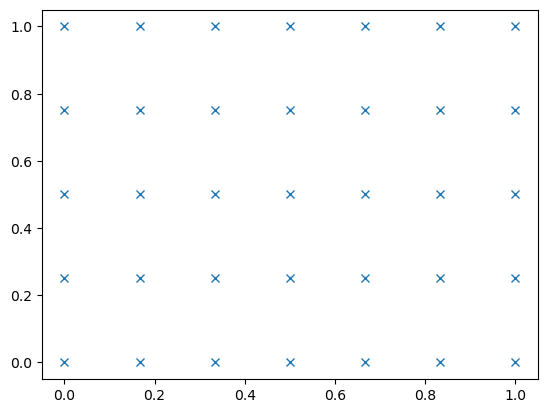

In [ ]:
pts = domain.geometry.x # mesh coordinates of the vertices shape=(num_points, 3)
pts = np.array(pts)
import matplotlib.pyplot as plt
plt.plot(pts[:, 0], pts[:,1], 'x')

In [ ]:
domain.geometry.dim # dimension of the euclidean coordinate system

2

In [ ]:
domain.topology.cell_name() # string representation of cell type of the mesh
domain.topology.original_cell_index

array([10, 11,  8, 22,  9, 23,  6, 20, 34,  7, 21, 35,  4, 18, 32, 46,  5,
       19, 33, 47,  2, 16, 30, 44,  3, 17, 31, 45,  0, 14, 28, 42,  1, 15,
       29, 43, 12, 26, 40, 13, 27, 41, 24, 38, 25, 39, 36, 37],
      dtype=int64)